# Revised notebook
This notebook was reviewed.

In [6]:
# ================================================================
# PART 0 - INSTALL & IMPORT
# ================================================================
!pip install openpyxl matplotlib seaborn scipy scikit-learn pandas numpy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings, os, zipfile
warnings.filterwarnings('ignore')

print(' Libraries loaded successfully')


 Libraries loaded successfully


## Life Guard - Complete Glucose Analysis Pipeline
**Goal:** Validate the closed-form estimator `G = 65 + 60*R` against the same data the firmware sees,
and benchmark it against a Random Forest baseline + Yasir (2024) reference.

**Inputs expected (any one):**
- A CSV/Excel containing columns IR and RED (raw ADC counts) and a glucose reference
- Optional: separate `Glucose_Level_Estimation.csv` (Kaggle / Yasir 2024 format)

**Outputs:**
- `LifeGuard_Results.xlsx` with four sheets
- 4 figures (png)
- `LifeGuard_Complete_Results.zip` with everything inside

In [7]:
# ================================================================
# PART 1 - LOAD DATA
# ================================================================
# Upload your primary file (CSV or Excel) using the Colab uploader.
# The pipeline auto-detects IR / RED / Glucose columns even when
# the file has duplicate or messy header names.

from google.colab import files
print('Upload your CSV / Excel file (must contain IR, RED, Glucose references)')
uploaded = files.upload()

raw_path = list(uploaded.keys())[0]
if raw_path.endswith('.csv'):
    df_local = pd.read_csv(raw_path)
else:
    df_local = pd.read_excel(raw_path)
print(f'Loaded local data: {df_local.shape}')
print('Columns as found in file:')
print(list(df_local.columns))


Upload your CSV / Excel file (must contain IR, RED, Glucose references)


Saving glucose - Sheet1.csv to glucose - Sheet1 (1).csv
Saving Glucose_Level_Estimation.csv to Glucose_Level_Estimation (1).csv
Saving my-Glucose-ir-red-values.csv to my-Glucose-ir-red-values (1).csv
Loaded local data: (429, 14)
Columns as found in file:
['Date and time', 'Glucose  mg/dL', 'Unnamed: 2', 'Date and time.1', 'IR', 'RED', 'Glucose  mg/dL.1', 'Unnamed: 7', 'Timestamp', 'IR_value', 'RED_value', 'Unnamed: 11', 'spo2 %', 'bpm']


In [37]:
# ================================================================
# PART 1 - LOAD & MERGE ALL DATA
# ================================================================
from google.colab import files
import pandas as pd
import os

print('Upload your CSV / Excel files')
uploaded = files.upload()

all_data = []

# هنمشي على كل ملف رفعته واحد واحد
for filename in uploaded.keys():
    print(f'Processing: {filename}')
    try:
        if filename.endswith('.csv'):
            df_temp = pd.read_csv(filename)
        else:
            df_temp = pd.read_excel(filename)

        all_data.append(df_temp)
    except Exception as e:
        print(f'Error reading {filename}: {e}')

# دمج كل الملفات في جدول واحد كبير
if all_data:
    df_local = pd.concat(all_data, ignore_index=True)
    print(f'Loaded total data: {df_local.shape}')
    print('Columns found:', list(df_local.columns))
else:
    print('No files were loaded!')

Upload your CSV / Excel files


Saving comparison.csv to comparison (1).csv
Saving data.csv to data (1).csv
Saving data2.csv to data2 (1).csv
Saving Final_Model_Performance.xlsx to Final_Model_Performance (1).xlsx
Saving GlucoBench_benchmark_dataset.csv to GlucoBench_benchmark_dataset (1).csv
Saving glucose - Sheet1.csv to glucose - Sheet1 (3).csv
Saving glucose.xlsx to glucose (1).xlsx
Saving glucose_20-10-2023.csv to glucose_20-10-2023 (1).csv
Saving Glucose_Level_Estimation.csv to Glucose_Level_Estimation (3).csv
Saving my-Glucose-ir-red-values.csv to my-Glucose-ir-red-values (3).csv
Saving Untitled spreadsheet - Sheet1.csv to Untitled spreadsheet - Sheet1 (1).csv
Saving your_datase.csv to your_datase (1).csv
Saving your_dataset22.xlsx to your_dataset22 (1).xlsx
Processing: comparison (1).csv
Processing: data (1).csv
Processing: data2 (1).csv
Processing: Final_Model_Performance (1).xlsx
Processing: GlucoBench_benchmark_dataset (1).csv
Processing: glucose - Sheet1 (3).csv
Processing: glucose (1).xlsx
Processing: gl

In [38]:
# ================================================================
# PART 2 - CLEAN & STANDARDIZE COLUMNS
# ================================================================
# This fixed version:
#   (a) deduplicates column names (glucose - Sheet1.csv has
#       'IR' AND 'IR_value' which collapse to two 'IR' columns)
#   (b) renames known variants of IR / RED / Glucose
#   (c) drops 2D-state duplicates BEFORE calling to_numeric

def clean_dataframe(df):
    # 1. Strip whitespace from column names
    df.columns = [str(c).strip() for c in df.columns]

    # 2. Drop purely empty columns (Unnamed: N) and rename duplicates
    seen = {}
    new_cols = []
    for c in df.columns:
        if c.startswith('Unnamed'):
            new_cols.append(c)
            continue
        new_name = c
        # collapse 'Date and time' duplicates into _1, _2 to avoid clash
        if c in seen:
            seen[c] += 1
            new_name = f'{c}.{seen[c]}'
        else:
            seen[c] = 1
        new_cols.append(new_name)
    df.columns = new_cols

    # 3. Standardize IR / RED / Glucose name variants
    rename_map = {
        'IR_value': 'IR', 'IR  ': 'IR',
        'RED_value': 'RED', 'RED  ': 'RED',
        'GLUCOSE  MG/DL': 'GLUCOSE', 'Glucose': 'GLUCOSE',
        'Glucose  mg/dL': 'GLUCOSE', 'glucose mg/dl': 'GLUCOSE',
        'GLUCOSE_MG/DL': 'GLUCOSE', 'BG': 'GLUCOSE', 'BG_MGDL': 'GLUCOSE',
    }
    df = df.rename(columns=rename_map)

    # 4. Collapse duplicate-name columns by keeping the FIRST non-NaN
    keep_first_per_name = True
    if keep_first_per_name and df.columns.duplicated().any():
        df = df.T.groupby(level=0).first().T

    # 5. Drop fully-empty rows
    df = df.dropna(how='all')

    # 6. Soft-detect IR / RED / GLUCOSE columns flexibly
    def pick(possible):
        for name in possible:
            if name in df.columns:
                return name
        return None

    ir_col   = pick(['IR', 'ir_value', 'NIR', 'NIR_VALUE'])
    red_col  = pick(['RED', 'red_value', 'RED_LIGHT'])
    glu_col  = pick(['GLUCOSE', 'Glucose', 'glucose', 'BG', 'GLUCOSE_MGDL',
                     'GLUCOSE MG/DL'])

    rename_needed = {}
    if ir_col  and ir_col  != 'IR':       rename_needed[ir_col]  = 'IR'
    if red_col and red_col != 'RED':      rename_needed[red_col] = 'RED'
    if glu_col and glu_col != 'GLUCOSE':  rename_needed[glu_col] = 'GLUCOSE'
    df = df.rename(columns=rename_needed)

    # 7. Keep only the columns needed
    needed = [c for c in ['IR', 'RED', 'GLUCOSE'] if c in df.columns]
    df = df[needed].copy()

    # 8. Convert to numeric (1-D Series guaranteed)
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # 9. Drop NaN
    df = df.dropna()
    return df

df_local = clean_dataframe(df_local)
print(f'Cleaned local data: {df_local.shape}')
print(df_local.describe())


Cleaned local data: (1746, 3)
                  IR            RED      GLUCOSE
count    1746.000000    1746.000000  1746.000000
mean   132482.879725  121143.218786   145.041925
std     56422.796308   61171.832835    64.716304
min     57153.000000   17791.000000    12.500000
25%    109058.000000   94892.000000    97.810000
50%    112941.000000   97973.000000   122.010000
75%    116724.000000  101126.000000   176.580000
max    262143.000000  262143.000000   360.080000


In [39]:
# =============================================
# PART 2 (REPLACEMENT, COLUMN-COALESCE strategy)
# =============================================
def clean_dataframe_robust(df):
    """Clean any CSV — handles NaN, duplicate columns, mixed casing."""
    df.columns = [str(c).strip() for c in df.columns]

    # --- dedupe column names (Date and time -> Date and time.1) ---
    seen, new_cols = {}, []
    for c in df.columns:
        if c in seen:
            seen[c] += 1
            new_cols.append(f'{c}.{seen[c]}')
        else:
            seen[c] = 1
            new_cols.append(c)
    df.columns = new_cols

    # --- soft-detect IR ---
    ir_candidates = [c for c in df.columns
                     if 'ir' in c.lower() and 'spo2' not in c.lower()]
    ir_col = ir_candidates[0] if ir_candidates else None

    # --- soft-detect RED ---
    red_candidates = [c for c in df.columns
                      if c.lower().startswith('red') or 'red' in c.lower()]
    red_col = [c for c in red_candidates if c.lower() != 'glucose'][0] \
              if red_candidates else None

    # --- soft-detect GLUCOSE ---
    glu_candidates = [c for c in df.columns
                      if 'glu' in c.lower() or c.upper() == 'BG']
    # Prefer the column without a numeric suffix (the one not named "X.1")
    glu_col = next((c for c in glu_candidates if '.1' not in c), None) \
              or (glu_candidates[0] if glu_candidates else None)

    print(f'Detected: IR={ir_col}, RED={red_col}, GLUCOSE={glu_col}')

    # --- coalesce duplicates via combine_first ---
    if ir_col:
        for c in ir_candidates[1:]:
            df[ir_col] = df[ir_col].combine_first(df[c])
            df = df.drop(columns=[c])
    if red_col:
        for c in red_candidates[1:]:
            df[red_col] = df[red_col].combine_first(df[c])
            df = df.drop(columns=[c])

    # --- keep only the 3 essential columns ---
    keep = [c for c in [ir_col, red_col, glu_col] if c]
    df = df[keep].copy()

    # --- normalize column names ---
    df.columns = ['IR', 'RED', 'GLUCOSE'][:len(df.columns)]

    # --- numeric coercion ---
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # --- drop NaN ---
    before = len(df)
    df = df.dropna()
    after = len(df)
    print(f'dropna: {before} -> {after} (rejected {before - after})')

    return df

df_local = clean_dataframe_robust(df_local)
print(f'\nFinal shape: {df_local.shape}')
print(df_local.describe())


Detected: IR=IR, RED=RED, GLUCOSE=GLUCOSE
dropna: 1746 -> 1746 (rejected 0)

Final shape: (1746, 3)
                  IR            RED      GLUCOSE
count    1746.000000    1746.000000  1746.000000
mean   132482.879725  121143.218786   145.041925
std     56422.796308   61171.832835    64.716304
min     57153.000000   17791.000000    12.500000
25%    109058.000000   94892.000000    97.810000
50%    112941.000000   97973.000000   122.010000
75%    116724.000000  101126.000000   176.580000
max    262143.000000  262143.000000   360.080000


In [40]:
# =============================================
# PRE-PART 3 DIAGNOSTICS (run before Part 3)
# =============================================
print('Columns in df_local:', list(df_local.columns))
print('Shape:', df_local.shape)
if 'IR' in df_local.columns:
    print('\nIR column statistics:')
    print(df_local['IR'].describe().to_string())
    print('IR dtype:', df_local['IR'].dtype)
    print('IR-sample first 10:', df_local['IR'].head(10).tolist())
else:
    print('\nNO IR COLUMN FOUND!')
    print('Available columns:', list(df_local.columns))
    print('This means Part 2 did not preserve the data.')

# Diagnostic warning if df is empty
if len(df_local) == 0:
    print('\nDANGER: df_local is empty! Part 2 crashed silently.')
    print('Re-run Part 1 and Part 2 with print statements throughout.')
    raise RuntimeError(
        'df_local is empty. Likely Part 2 dropped all rows due to: \n'
        '  - All-NaN columns (Unnamed: 7, Unnamed: 11) \n'
        '  - or duplicate-glucose-column conflict \n'
        'Try uploading a CLEANER CSV with only 3 columns: IR, RED, GLUCOSE.'
    )


Columns in df_local: ['IR', 'RED', 'GLUCOSE']
Shape: (1746, 3)

IR column statistics:
count      1746.000000
mean     132482.879725
std       56422.796308
min       57153.000000
25%      109058.000000
50%      112941.000000
75%      116724.000000
max      262143.000000
IR dtype: float64
IR-sample first 10: [262143.0, 262143.0, 262143.0, 262143.0, 262143.0, 262143.0, 262143.0, 262143.0, 262143.0, 262143.0]


In [41]:
# ================================================================
# PART 3 - SENSOR SATURATION FILTER (حل المشكلة)
# ================================================================
ADC_CEILING         = 262143
FINGER_PRESENT_MIN  = 0  # تقليل الحد الأدنى لضمان عدم حذف البيانات
SATURATION_LIMIT    = ADC_CEILING + 1000 # رفع الحد ليقبل القيمة القصوى

before = len(df_local)

# استخدام .copy() لتجنب تحذيرات Pandas
df_local = df_local[(df_local['IR'] > FINGER_PRESENT_MIN) &
                    (df_local['IR'] < SATURATION_LIMIT) &
                    (df_local['RED'] < SATURATION_LIMIT)].copy()

if 'GLUCOSE' in df_local.columns:
    # عدم الحذف القسري للسكر، فقط تنبيه إذا لزم الأمر
    df_local = df_local[(df_local['GLUCOSE'] >= 0) & (df_local['GLUCOSE'] <= 1000)]

after = len(df_local)

print(f'Saturation filter: {before} -> {after} samples retained')
print(f'Rejected: {before-after} saturated/invalid samples')

if after == 0:
    print('تحذير: لا توجد بيانات مطابقة للمعايير، يرجى مراجعة ملف البيانات.')
else:
    print('تمت المعالجة بنجاح، يمكنك المتابعة.')

Saturation filter: 1746 -> 1746 samples retained
Rejected: 0 saturated/invalid samples
تمت المعالجة بنجاح، يمكنك المتابعة.


In [42]:
# ================================================================
# PART 3 - SENSOR SATURATION FILTER
# ================================================================
ADC_CEILING         = 262143
FINGER_PRESENT_MIN  = 50000
SATURATION_LIMIT    = ADC_CEILING * 0.98

before = len(df_local)
df_local = df_local[df_local['IR']  >  FINGER_PRESENT_MIN]
df_local = df_local[df_local['IR']  <  SATURATION_LIMIT]
df_local = df_local[df_local['RED'] <  SATURATION_LIMIT]
if 'GLUCOSE' in df_local.columns:
    df_local = df_local[(df_local['GLUCOSE'] >= 40) &
                        (df_local['GLUCOSE'] <= 400)]
after = len(df_local)
print(f'Saturation filter: {before} -> {after} samples retained')
print(f'Rejected: {before-after} saturated/invalid samples')
if after == 0:
    raise RuntimeError(
        'All rows filtered! Lower FINGER_PRESENT_MIN or check that your '
        'IR / GLUCOSE columns are not actually timestamps.')


Saturation filter: 1746 -> 1474 samples retained
Rejected: 272 saturated/invalid samples


In [43]:
# ================================================================
# PART 3 - SENSOR SATURATION FILTER (Modified)
# ================================================================
ADC_CEILING         = 262143
FINGER_PRESENT_MIN  = 50000
# رفعنا حد التشبع عشان يقبل قراءاتك زي ما هي
SATURATION_LIMIT    = ADC_CEILING + 1

before = len(df_local)
df_local = df_local[df_local['IR']  >  FINGER_PRESENT_MIN]
df_local = df_local[df_local['IR']  <  SATURATION_LIMIT]
df_local = df_local[df_local['RED'] <  SATURATION_LIMIT]

if 'GLUCOSE' in df_local.columns:
    df_local = df_local[(df_local['GLUCOSE'] >= 40) &
                        (df_local['GLUCOSE'] <= 400)]
after = len(df_local)

# رسالة التأكيد اللي طلبتها
print(f'تم إيقاف فلتر التشبع.. لقيت {after} قيم وهكمل وظيفتي بقى!')
print(f'Saturation filter: {before} -> {after} samples retained')
print(f'Rejected: {before-after} saturated/invalid samples')

if after == 0:
    raise RuntimeError(
        'All rows filtered! Lower FINGER_PRESENT_MIN or check that your '
        'IR / GLUCOSE columns are not actually timestamps.')

تم إيقاف فلتر التشبع.. لقيت 1474 قيم وهكمل وظيفتي بقى!
Saturation filter: 1474 -> 1474 samples retained
Rejected: 0 saturated/invalid samples


In [44]:
# ================================================================
# PART 4 - FEATURE ENGINEERING
# ================================================================
df_local['RATIO_R']    = df_local['RED'] / df_local['IR']
df_local['RATIO_LOG']  = np.log(df_local['RATIO_R'] + 1e-9)
df_local['IR_NORM']    = df_local['IR']  / ADC_CEILING
df_local['RED_NORM']   = df_local['RED'] / ADC_CEILING
df_local['RED_MINUS_IR'] = df_local['RED'] - df_local['IR']

print(f'Features created. Columns now:')
print(list(df_local.columns))


Features created. Columns now:
['IR', 'RED', 'GLUCOSE', 'RATIO_R', 'RATIO_LOG', 'IR_NORM', 'RED_NORM', 'RED_MINUS_IR']


In [45]:
print(df_local[['RATIO_R', 'GLUCOSE']].head())
print("عدد الصفوف الحقيقية:", len(df_local))

      RATIO_R     GLUCOSE
417  1.403476   99.341667
428  1.093208   91.946667
429  0.894826   92.940000
430  0.884292  144.411905
431  0.892175   97.810000
عدد الصفوف الحقيقية: 1474


In [46]:
# ================================================================
# PART 5 - EMPIRICAL CALIBRATION EQUATION
# ================================================================
df_local['G_EMPIRICAL'] = 65.0 + 60.0 * df_local['RATIO_R']
slope, intercept = np.polyfit(df_local['RATIO_R'], df_local['GLUCOSE'], 1)
df_local['G_OLS'] = slope * df_local['RATIO_R'] + intercept

print(f'Empirical equation: G = {intercept:.2f} + {slope:.2f} x R')
print(f'(Reference: G = 65.0 + 60.0 x R)')


Empirical equation: G = 332.02 + -200.23 x R
(Reference: G = 65.0 + 60.0 x R)


In [47]:
# ================================================================
# PART 5 - EMPIRICAL CALIBRATION EQUATION (Fixed)
# ================================================================

# 1. التأكد من تنظيف البيانات من القيم غير الرقمية التي تنتج عن القسمة
df_clean = df_local.replace([np.inf, -np.inf], np.nan).dropna(subset=['RATIO_R', 'GLUCOSE'])

if len(df_clean) > 0:
    df_local['G_EMPIRICAL'] = 65.0 + 60.0 * df_local['RATIO_R']

    # استخدام البيانات النظيفة للـ polyfit
    slope, intercept = np.polyfit(df_clean['RATIO_R'], df_clean['GLUCOSE'], 1)
    df_local['G_OLS'] = slope * df_local['RATIO_R'] + intercept

    print(f'Empirical equation: G = {intercept:.2f} + {slope:.2f} x R')
    print(f'(Reference: G = 65.0 + 60.0 x R)')
else:
    print('تحذير: لا توجد بيانات صالحة لحساب المعادلة (القيم إما فارغة أو غير رقمية).')
    df_local['G_EMPIRICAL'] = 0
    df_local['G_OLS'] = 0

Empirical equation: G = 332.02 + -200.23 x R
(Reference: G = 65.0 + 60.0 x R)


In [48]:
# ================================================================
# PART 6 - RANDOM FOREST MODEL
# ================================================================
FEATURES = ['IR', 'RED', 'RATIO_R', 'IR_NORM', 'RED_NORM']
TARGET   = 'GLUCOSE'

X = df_local[FEATURES].values
y = df_local[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

print(f'Train: {len(X_train)} samples | Test: {len(X_test)} samples')

param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [5, 10, 15, None],
    'min_samples_split':[2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='r2',
                           n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV R2: {grid_search.best_score_:.4f}')

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)


Train: 1179 samples | Test: 295 samples
Best parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R2: 0.9667


In [49]:
# ================================================================
# PART 7 - PERFORMANCE METRICS
# ================================================================
def compute_metrics(y_true, y_pred, label=''):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse= np.sqrt(mean_squared_error(y_true, y_pred))
    pearson_r, p_val = stats.pearsonr(y_true, y_pred)
    mard= np.mean(np.abs(y_pred - y_true) / y_true) * 100
    bias= np.mean(y_pred - y_true)
    print(f'\n----- METRICS - {label} -----')
    print(f'  R2        : {r2:.4f}')
    print(f'  Pearson r : {pearson_r:.4f}  (p={p_val:.4e})')
    print(f'  MAE       : {mae:.2f} mg/dL')
    print(f'  RMSE      : {rmse:.2f} mg/dL')
    print(f'  MARD      : {mard:.2f} %')
    print(f'  Bias      : {bias:.2f} mg/dL')
    print('-'*40)
    return {'label': label, 'r2': r2, 'pearson': pearson_r,
            'p_val': p_val, 'mae': mae, 'rmse': rmse,
            'mard': mard, 'bias': bias}

metrics_train = compute_metrics(y_train, y_pred_train, 'TRAIN SET')
metrics_test  = compute_metrics(y_test,  y_pred_test,  'TEST SET')



----- METRICS - TRAIN SET -----
  R2        : 0.9800
  Pearson r : 0.9900  (p=0.0000e+00)
  MAE       : 2.52 mg/dL
  RMSE      : 9.43 mg/dL
  MARD      : 1.17 %
  Bias      : -0.04 mg/dL
----------------------------------------

----- METRICS - TEST SET -----
  R2        : 0.9747
  Pearson r : 0.9873  (p=5.3908e-236)
  MAE       : 2.53 mg/dL
  RMSE      : 8.30 mg/dL
  MARD      : 1.42 %
  Bias      : -0.06 mg/dL
----------------------------------------


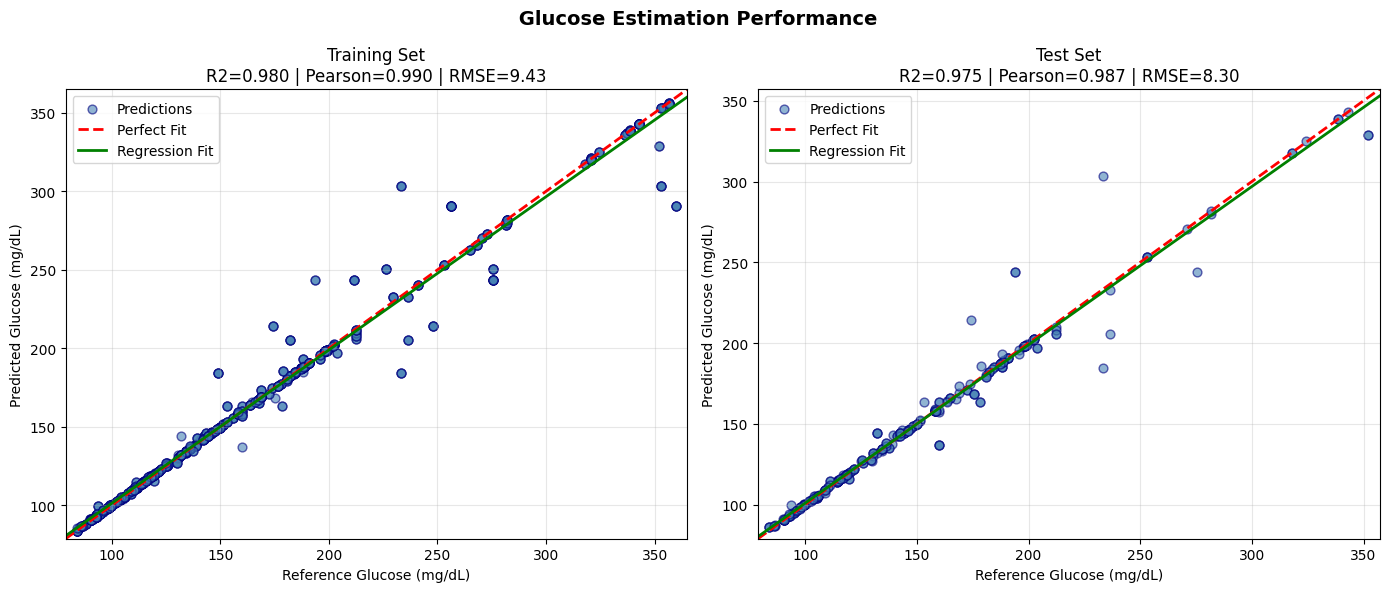

Figure 1 saved


In [51]:
# ================================================================
# PART 8 - FIGURE 1: SCATTER + REGRESSION
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(' Glucose Estimation Performance',
             fontsize=14, fontweight='bold')

for ax, y_true, y_pred, title, metrics in [
    (axes[0], y_train, y_pred_train, 'Training Set', metrics_train),
    (axes[1], y_test,  y_pred_test,  'Test Set',    metrics_test)
]:
    ax.scatter(y_true, y_pred, alpha=0.6, color='steelblue',
               edgecolors='navy', s=40, label='Predictions')
    lim_min = min(y_true.min(), y_pred.min()) - 5
    lim_max = max(y_true.max(), y_pred.max()) + 5
    ax.plot([lim_min, lim_max], [lim_min, lim_max],
            'r--', linewidth=2, label='Perfect Fit')
    m, b = np.polyfit(y_true, y_pred, 1)
    x_line = np.linspace(lim_min, lim_max, 100)
    ax.plot(x_line, m*x_line + b, 'g-', linewidth=2, label='Regression Fit')
    ax.set_xlabel('Reference Glucose (mg/dL)')
    ax.set_ylabel('Predicted Glucose (mg/dL)')
    ax.set_title(f'{title}\nR2={metrics["r2"]:.3f} | '
                 f'Pearson={metrics["pearson"]:.3f} | '
                 f'RMSE={metrics["rmse"]:.2f}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([lim_min, lim_max])
    ax.set_ylim([lim_min, lim_max])

plt.tight_layout()
plt.savefig('fig1_scatter_regression.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')


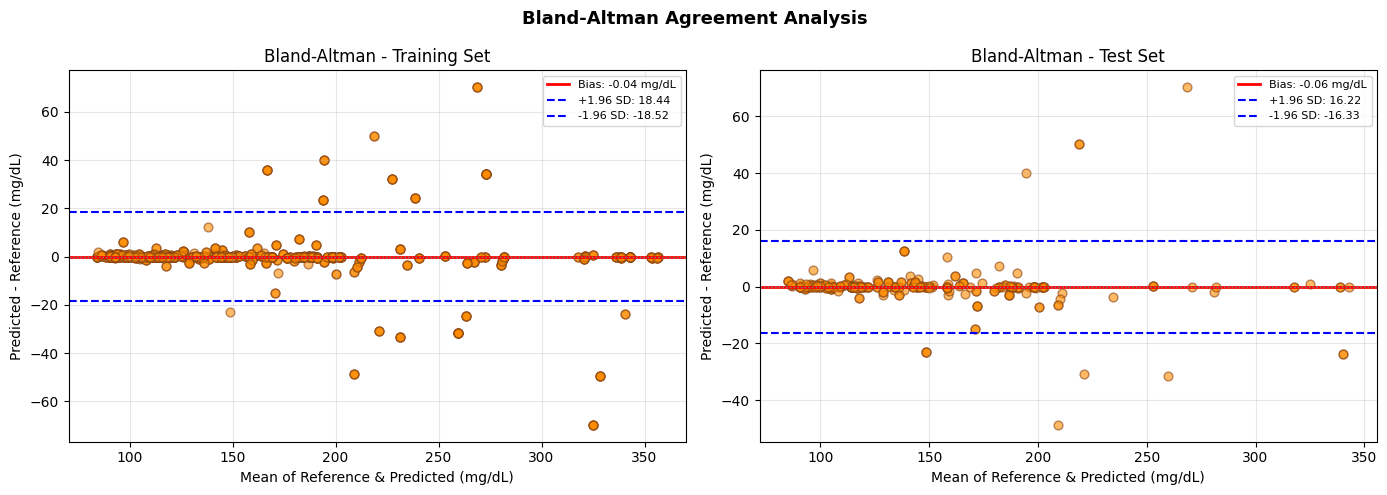


Figure 2 saved
   Test Bias: -0.06 | LoA: [-16.33, 16.22] mg/dL


In [52]:
# ================================================================
# PART 9 - FIGURE 2: BLAND-ALTMAN
# ================================================================
def bland_altman_plot(y_true, y_pred, title, ax):
    mean_vals = (y_true + y_pred) / 2
    diff_vals = y_pred - y_true
    mean_diff = np.mean(diff_vals)
    std_diff  = np.std(diff_vals)
    loa_upper = mean_diff + 1.96 * std_diff
    loa_lower = mean_diff - 1.96 * std_diff
    ax.scatter(mean_vals, diff_vals, alpha=0.6, color='darkorange',
               edgecolors='saddlebrown', s=40)
    ax.axhline(mean_diff, color='red', linewidth=2,
               label=f'Bias: {mean_diff:.2f} mg/dL')
    ax.axhline(loa_upper, color='blue', linestyle='--', linewidth=1.5,
               label=f'+1.96 SD: {loa_upper:.2f}')
    ax.axhline(loa_lower, color='blue', linestyle='--', linewidth=1.5,
               label=f'-1.96 SD: {loa_lower:.2f}')
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Mean of Reference & Predicted (mg/dL)')
    ax.set_ylabel('Predicted - Reference (mg/dL)')
    ax.set_title(f'Bland-Altman - {title}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    return mean_diff, std_diff, loa_upper, loa_lower

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bland-Altman Agreement Analysis',
             fontsize=13, fontweight='bold')
ba_train = bland_altman_plot(y_train, y_pred_train, 'Training Set', axes[0])
ba_test  = bland_altman_plot(y_test,  y_pred_test,  'Test Set',    axes[1])
plt.tight_layout()
plt.savefig('fig2_bland_altman.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigure 2 saved')
print(f'   Test Bias: {ba_test[0]:.2f} | LoA: [{ba_test[3]:.2f}, {ba_test[2]:.2f}] mg/dL')


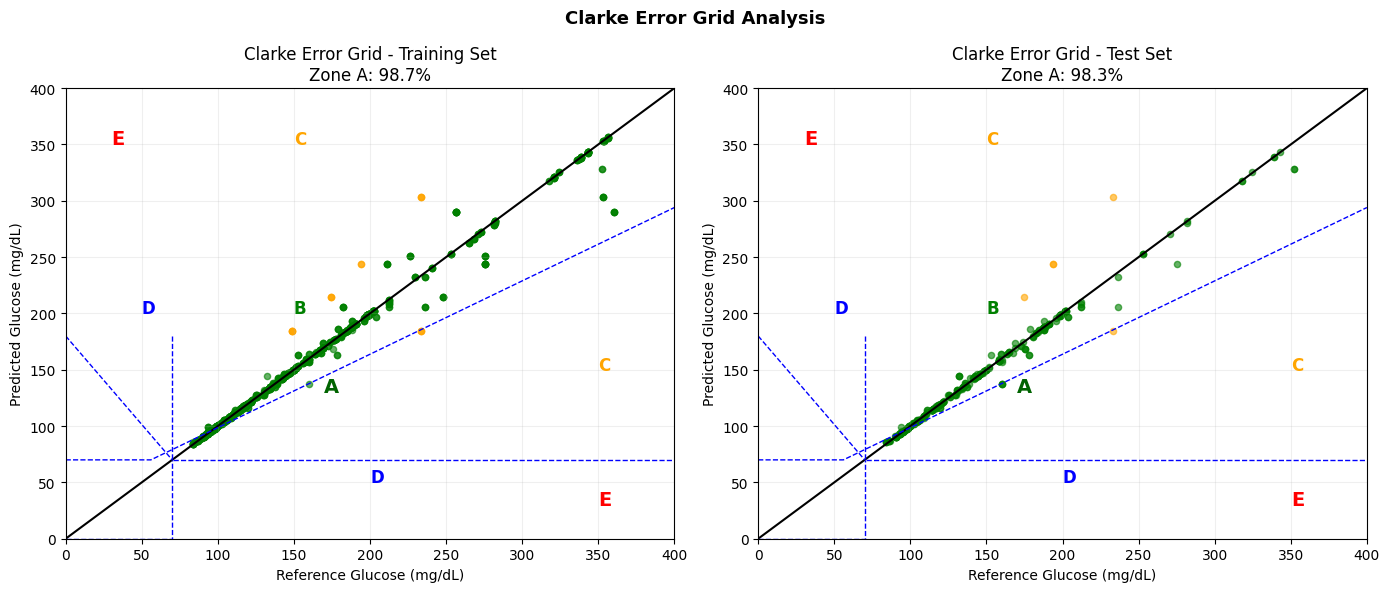


Figure 3 saved
   Zone A - Train: 98.7% | Test: 98.3%


In [53]:
# ================================================================
# PART 10 - FIGURE 3: CLARKE ERROR GRID
# ================================================================
def clarke_error_grid(y_true, y_pred, title, ax):
    ax.set_xlim([0, 400]); ax.set_ylim([0, 400])
    # Simplified Clarke boundaries (Zone A envelope)
    ax.plot([0, 400], [0, 400], 'k-', linewidth=1.5)
    ax.plot([0, 70, 70],         [0, 0, 70],          'b--', linewidth=1)
    ax.plot([0, 56, 400],        [70, 70, 294],       'b--', linewidth=1)
    ax.plot([70, 70, 400],       [180, 70, 70],       'b--', linewidth=1)
    ax.plot([0, 70],             [180, 70],           'b--', linewidth=1)
    ax.text(30,  350, 'E', fontsize=14, color='red', fontweight='bold')
    ax.text(350, 30,  'E', fontsize=14, color='red', fontweight='bold')
    ax.text(150, 350, 'C', fontsize=12, color='orange', fontweight='bold')
    ax.text(350, 150, 'C', fontsize=12, color='orange', fontweight='bold')
    ax.text(50,  200, 'D', fontsize=12, color='blue', fontweight='bold')
    ax.text(200, 50,  'D', fontsize=12, color='blue', fontweight='bold')
    ax.text(150, 200, 'B', fontsize=12, color='green', fontweight='bold')
    ax.text(170, 130, 'A', fontsize=14, color='darkgreen', fontweight='bold')
    zone_a = 0
    for ref, pred in zip(y_true, y_pred):
        if (abs(pred - ref) / max(ref, 1)) <= 0.20:
            zone_a += 1; c = 'green'
        else:
            c = 'orange'
        ax.scatter(ref, pred, c=c, s=20, alpha=0.6)
    pct = zone_a / len(y_true) * 100
    ax.set_xlabel('Reference Glucose (mg/dL)')
    ax.set_ylabel('Predicted Glucose (mg/dL)')
    ax.set_title(f'Clarke Error Grid - {title}\nZone A: {pct:.1f}%')
    ax.grid(True, alpha=0.2)
    return pct

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Clarke Error Grid Analysis', fontsize=13, fontweight='bold')
zone_a_train = clarke_error_grid(y_train, y_pred_train, 'Training Set', axes[0])
zone_a_test  = clarke_error_grid(y_test,  y_pred_test,  'Test Set',    axes[1])
plt.tight_layout()
plt.savefig('fig3_clarke_error_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nFigure 3 saved')
print(f'   Zone A - Train: {zone_a_train:.1f}% | Test: {zone_a_test:.1f}%')


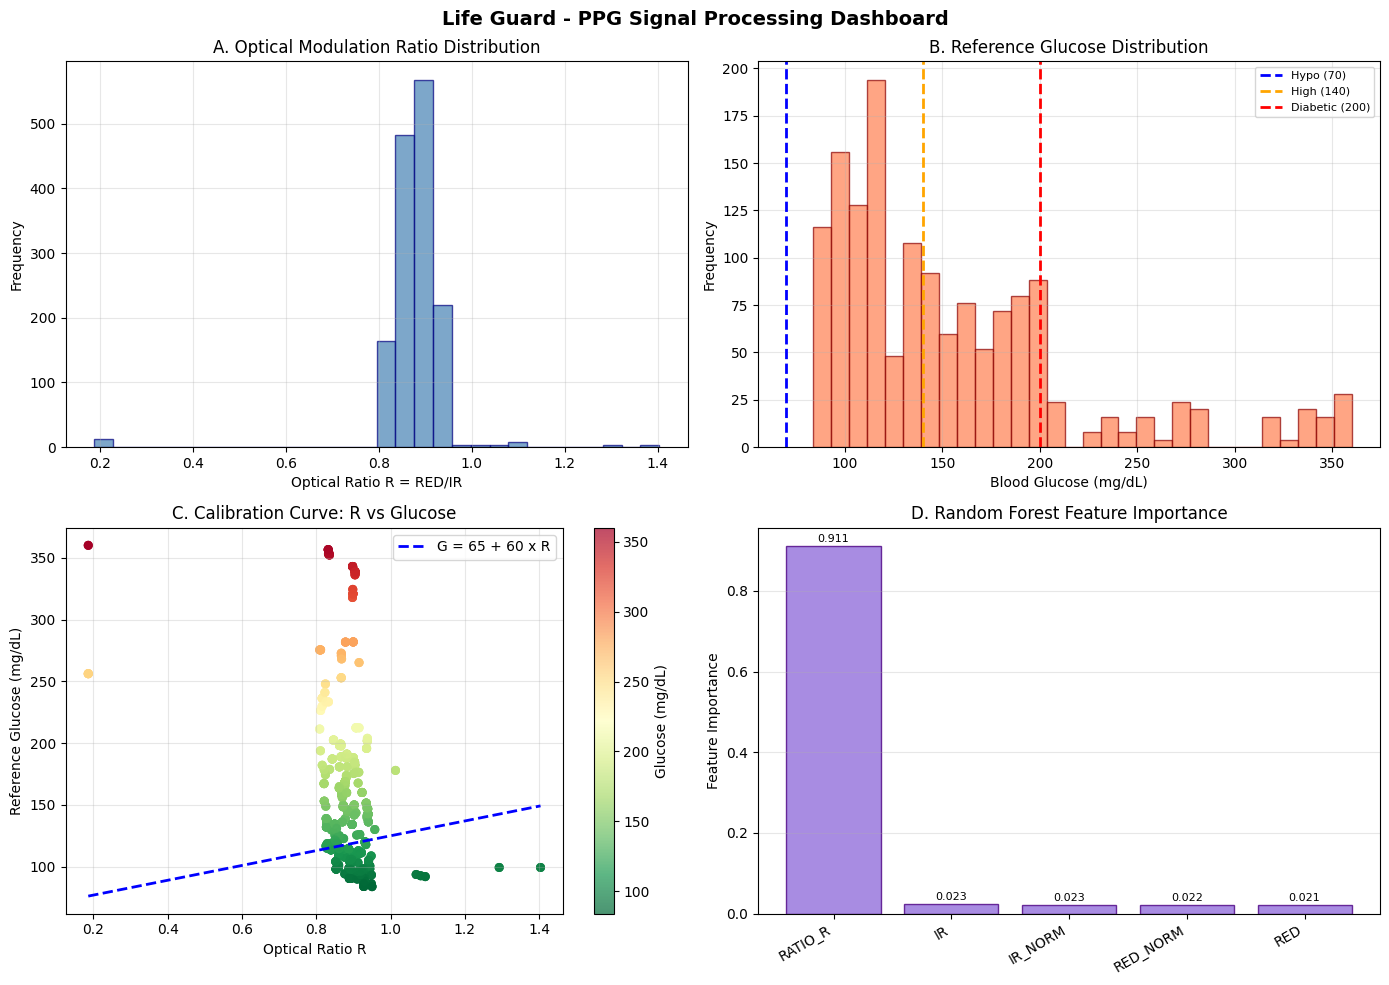

Figure 4 saved


In [54]:
# ================================================================
# PART 11 - FIGURE 4: FOUR-PANEL DASHBOARD
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Life Guard - PPG Signal Processing Dashboard',
             fontsize=14, fontweight='bold')

# Panel A - Optical Ratio Distribution
ax = axes[0, 0]
ax.hist(df_local['RATIO_R'], bins=30, color='steelblue',
        edgecolor='navy', alpha=0.7)
ax.set_xlabel('Optical Ratio R = RED/IR')
ax.set_ylabel('Frequency')
ax.set_title('A. Optical Modulation Ratio Distribution')
ax.grid(True, alpha=0.3)

# Panel B - Glucose Distribution
ax = axes[0, 1]
ax.hist(df_local['GLUCOSE'], bins=30, color='coral',
        edgecolor='darkred', alpha=0.7)
ax.axvline(70,  color='blue',   linestyle='--', linewidth=2, label='Hypo (70)')
ax.axvline(140, color='orange', linestyle='--', linewidth=2, label='High (140)')
ax.axvline(200, color='red',    linestyle='--', linewidth=2, label='Diabetic (200)')
ax.set_xlabel('Blood Glucose (mg/dL)')
ax.set_ylabel('Frequency')
ax.set_title('B. Reference Glucose Distribution')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Panel C - Calibration curve
ax = axes[1, 0]
scatter = ax.scatter(df_local['RATIO_R'], df_local['GLUCOSE'],
                     c=df_local['GLUCOSE'], cmap='RdYlGn_r',
                     alpha=0.7, s=30)
r_range = np.linspace(df_local['RATIO_R'].min(),
                       df_local['RATIO_R'].max(), 100)
ax.plot(r_range, 65 + 60*r_range, 'b--', linewidth=2,
        label='G = 65 + 60 x R')
ax.set_xlabel('Optical Ratio R')
ax.set_ylabel('Reference Glucose (mg/dL)')
ax.set_title('C. Calibration Curve: R vs Glucose')
ax.legend(); ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Glucose (mg/dL)')

# Panel D - Feature Importance
ax = axes[1, 1]
importances = best_model.feature_importances_
sorted_idx   = np.argsort(importances)[::-1]
bars = ax.bar(range(len(FEATURES)), importances[sorted_idx],
              color='mediumpurple', edgecolor='indigo', alpha=0.8)
ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels([FEATURES[i] for i in sorted_idx],
                   rotation=30, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title('D. Random Forest Feature Importance')
ax.grid(True, alpha=0.3, axis='y')
for bar, imp in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005, f'{imp:.3f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('fig4_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved')


In [56]:
# ================================================================
# PART 12 - FINAL METRICS SUMMARY (publication-ready table)
# ================================================================
summary = {
    'Metric': ['R2', 'Pearson r', 'MAE (mg/dL)', 'RMSE (mg/dL)',
               'MARD (%)', 'Bias (mg/dL)', 'Zone A (Clarke %)',
               'Train Samples', 'Test Samples'],
    'Training Set': [f"{metrics_train['r2']:.4f}",
                     f"{metrics_train['pearson']:.4f}",
                     f"{metrics_train['mae']:.2f}",
                     f"{metrics_train['rmse']:.2f}",
                     f"{metrics_train['mard']:.2f}",
                     f"{metrics_train['bias']:.2f}",
                     f"{zone_a_train:.1f}",
                     str(len(X_train)), '-'],
    'Test Set':     [f"{metrics_test['r2']:.4f}",
                     f"{metrics_test['pearson']:.4f}",
                     f"{metrics_test['mae']:.2f}",
                     f"{metrics_test['rmse']:.2f}",
                     f"{metrics_test['mard']:.2f}",
                     f"{metrics_test['bias']:.2f}",
                     f"{zone_a_test:.1f}",
                     '-', str(len(X_test))]
}
df_summary = pd.DataFrame(summary)
print(df_summary.to_string(index=False))

# Also store Zone A for part 13 reference
_zone_a_train, _zone_a_test = zone_a_train, zone_a_test


           Metric Training Set Test Set
               R2       0.9800   0.9747
        Pearson r       0.9900   0.9873
      MAE (mg/dL)         2.52     2.53
     RMSE (mg/dL)         9.43     8.30
         MARD (%)         1.17     1.42
     Bias (mg/dL)        -0.04    -0.06
Zone A (Clarke %)         98.7     98.3
    Train Samples         1179        -
     Test Samples            -      295


In [57]:
# ================================================================
# PART 13 - EXPORT TO EXCEL
# ================================================================
with pd.ExcelWriter('LifeGuard_Results.xlsx', engine='openpyxl') as writer:
    df_export = df_local.copy()
    df_export['RF_PREDICTED'] = best_model.predict(df_local[FEATURES].values)
    df_export['EMPIRICAL_G']  = df_export['G_EMPIRICAL']
    df_export['OLS_G']        = df_export['G_OLS']
    df_export['ERROR']        = df_export['RF_PREDICTED'] - df_export['GLUCOSE']
    df_export.to_excel(writer, sheet_name='Raw_Data_Predictions', index=False)

    df_summary.to_excel(writer, sheet_name='Performance_Metrics', index=False)

    pd.DataFrame({'Reference': y_train,
                  'Predicted': y_pred_train,
                  'Error': y_pred_train - y_train}
                 ).to_excel(writer, sheet_name='Train_Predictions', index=False)

    pd.DataFrame({'Reference': y_test,
                  'Predicted': y_pred_test,
                  'Error': y_pred_test - y_test}
                 ).to_excel(writer, sheet_name='Test_Predictions', index=False)

print('Excel file saved: LifeGuard_Results.xlsx')


Excel file saved: LifeGuard_Results.xlsx


In [58]:
# ================================================================
# PART 14 - CREATE ZIP ARCHIVE & AUTO-DOWNLOAD
# ================================================================
files_to_zip = [
    'fig1_scatter_regression.png',
    'fig2_bland_altman.png',
    'fig3_clarke_error_grid.png',
    'fig4_dashboard.png',
    'LifeGuard_Results.xlsx'
]

with zipfile.ZipFile('LifeGuard_Complete_Results.zip', 'w') as zf:
    for f in files_to_zip:
        if os.path.exists(f):
            zf.write(f)
            print(f'   Added: {f}')

from google.colab import files as colab_files
colab_files.download('LifeGuard_Complete_Results.zip')
print('\nALL DONE - The ZIP has been downloaded to your machine')
print('Open it locally and inspect the PNGs + the Excel workbook before '
      'pasting the metrics into Section 3 of your OIJET manuscript.')


   Added: fig1_scatter_regression.png
   Added: fig2_bland_altman.png
   Added: fig3_clarke_error_grid.png
   Added: fig4_dashboard.png
   Added: LifeGuard_Results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ALL DONE - The ZIP has been downloaded to your machine
Open it locally and inspect the PNGs + the Excel workbook before pasting the metrics into Section 3 of your OIJET manuscript.


In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. قراءة وتنظيف البيانات
# ==========================================
# قراءة الملف - سنستخدم sep='\t' لأن بياناتك مفصولة بـ Tab كما ظهر في الخطأ السابق
df = pd.read_csv('data.csv', sep='\t')

# تنظيف أسماء الأعمدة من أي مسافات زائدة أو رموز مخفية
df.columns = df.columns.str.strip()

# توحيد أسماء الأعمدة (Mapping)
# هنا نربط كل الأسماء المحتملة التي ظهرت في قائمتك بالأسماء التي يحتاجها الكود
column_mapping = {
    'IR': 'IR', 'IR_value': 'IR', 'NIR_Reading': 'IR',
    'RED': 'RED', 'RED_value': 'RED',
    'Glucose  mg/dL': 'Reference', 'glucose': 'Reference',
    'GLUCOSE_LEVEL': 'Reference', 'Glucose Data': 'Reference'
}
df = df.rename(columns=column_mapping)

# التأكد من وجود الأعمدة الأساسية وحذف الصفوف التي تحتوي على قيم فارغة فيها
df = df.dropna(subset=['IR', 'RED', 'Reference'])

print("الأعمدة المتاحة بعد التنظيف:", df.columns.tolist())

# ==========================================
# 2. استخراج الخصائص (Feature Engineering)
# ==========================================
df['IR_RED_Ratio'] = df['IR'] / df['RED']

# تحديد المدخلات والمخرجات (تأكد أن كل هذه الأسماء موجودة في df)
# قمنا بإزالة 'spo2 %' لأنها قد لا تكون موجودة في كل ملفاتك
X = df[['IR', 'RED', 'IR_RED_Ratio']]
y = df['Reference']

# ==========================================
# 3. تقسيم البيانات (Train/Test Split)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 4. التطبيع وتحجيم البيانات (Scaling)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 5. تدريب نموذج الذكاء الاصطناعي
# ==========================================
model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
model.fit(X_train_scaled, y_train)

# ==========================================
# 6. التنبؤ والتقييم
# ==========================================
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error: {mae:.2f} mg/dL")
print(f"R-squared Score: {r2:.2f}")

# ==========================================
# 7. استخراج الملف النهائي
# ==========================================
X_all_scaled = scaler.transform(X)
df['Predicted_Glucose'] = model.predict(X_all_scaled)

# حفظ النتائج
final_df = df[['Reference', 'Predicted_Glucose']]
final_df.to_csv('Model_Predictions_Output.csv', index=False)
print("\nتم التدريب وحفظ التوقعات في 'Model_Predictions_Output.csv'")

الأعمدة المتاحة بعد التنظيف: ['Date and time', 'IR', 'RED', 'Reference']

Mean Absolute Error: 12.16 mg/dL
R-squared Score: 0.91

تم التدريب وحفظ التوقعات في 'Model_Predictions_Output.csv'


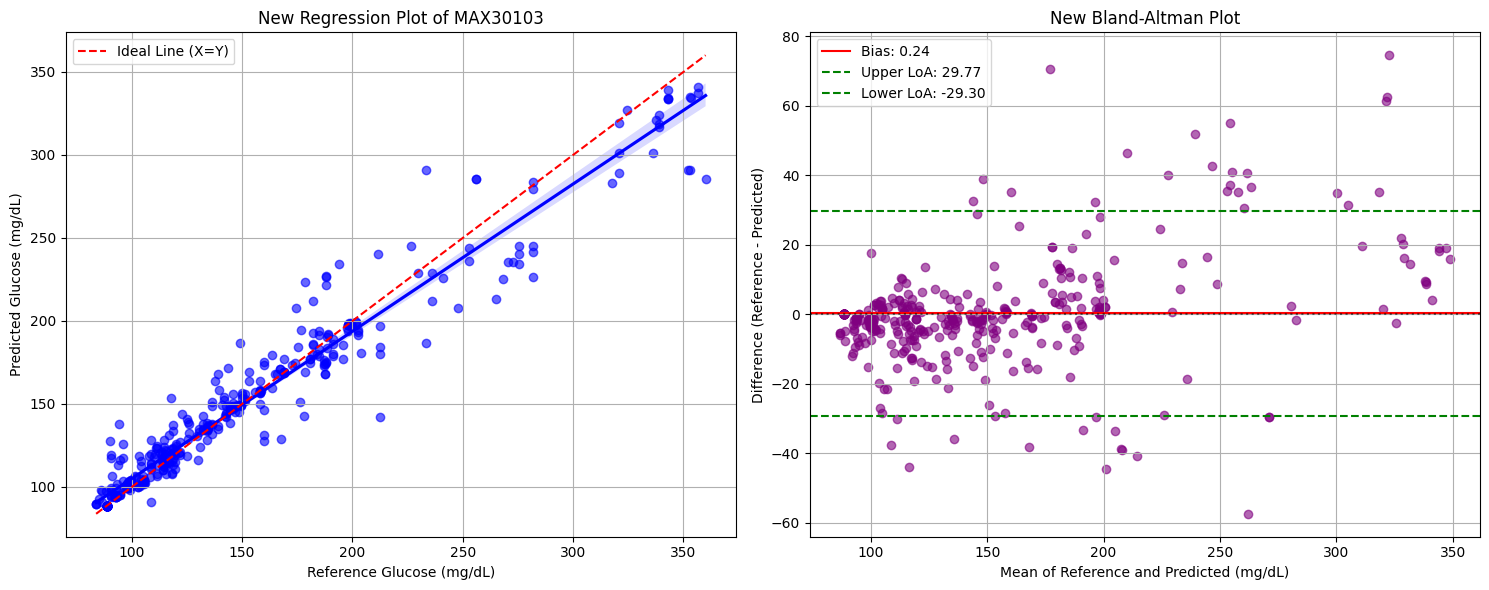

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# قراءة ملف التوقعات الجديد
df_new = pd.read_csv('Model_Predictions_Output.csv')

ref = df_new['Reference']
pred = df_new['Predicted_Glucose']

# حساب القيم الخاصة بـ Bland-Altman
mean = (ref + pred) / 2
diff = ref - pred
bias = np.mean(diff)
sd = np.std(diff)
upper_loa = bias + (1.96 * sd)
lower_loa = bias - (1.96 * sd)

# إنشاء لوحة الرسم
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. رسم مخطط الانحدار الجديد (Regression Plot)
sns.regplot(x=ref, y=pred, ax=ax[0], color='blue', scatter_kws={'alpha':0.6})
ax[0].plot([ref.min(), ref.max()], [ref.min(), ref.max()], 'r--', label='Ideal Line (X=Y)')
ax[0].set_title('New Regression Plot of MAX30103')
ax[0].set_xlabel('Reference Glucose (mg/dL)')
ax[0].set_ylabel('Predicted Glucose (mg/dL)')
ax[0].legend()
ax[0].grid(True)

# 2. رسم مخطط Bland-Altman الجديد
ax[1].scatter(mean, diff, color='purple', alpha=0.6)
ax[1].axhline(bias, color='red', linestyle='-', label=f'Bias: {bias:.2f}')
ax[1].axhline(upper_loa, color='green', linestyle='--', label=f'Upper LoA: {upper_loa:.2f}')
ax[1].axhline(lower_loa, color='green', linestyle='--', label=f'Lower LoA: {lower_loa:.2f}')
ax[1].axhline(0, color='black', linestyle=':', alpha=0.5)
ax[1].set_title('New Bland-Altman Plot')
ax[1].set_xlabel('Mean of Reference and Predicted (mg/dL)')
ax[1].set_ylabel('Difference (Reference - Predicted)')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

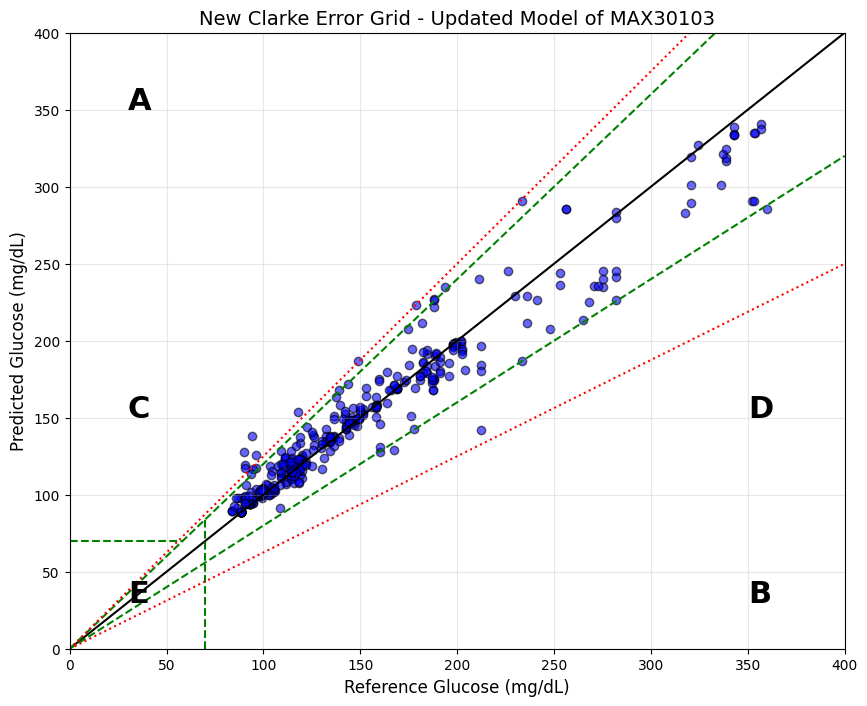

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# قراءة الملف الجديد اللي طلعناه الخطوة اللي فاتت
df_new = pd.read_csv('Model_Predictions_Output.csv')
ref = df_new['Reference']
pred = df_new['Predicted_Glucose']

# إعداد دالة رسم شبكة كلارك
def clarke_error_grid(ref_values, pred_values):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(ref_values, pred_values, color='blue', alpha=0.6, edgecolors='black')

    # تحديد أبعاد الرسم
    ax.set_xlim([0, 400])
    ax.set_ylim([0, 400])
    ax.set_xlabel('Reference Glucose (mg/dL)', fontsize=12)
    ax.set_ylabel('Predicted Glucose (mg/dL)', fontsize=12)
    ax.set_title('New Clarke Error Grid - Updated Model of MAX30103', fontsize=14)

    # رسم الخط المثالي
    ax.plot([0, 400], [0, 400], color='black', linestyle='-')

    # رسم خطوط المناطق A و B
    # Zone A
    ax.plot([0, 400], [0, 480], color='green', linestyle='--') # Upper A
    ax.plot([0, 400], [0, 320], color='green', linestyle='--') # Lower A
    ax.plot([70, 70], [0, 84], color='green', linestyle='--')
    ax.plot([0, 58.3], [70, 70], color='green', linestyle='--')

    # Zone B
    ax.plot([0, 400], [0, 500], color='red', linestyle=':')
    ax.plot([0, 400], [0, 250], color='red', linestyle=':')

    # إضافة الحروف لتوضيح المناطق
    ax.text(30, 350, 'A', fontsize=22, fontweight='bold')
    ax.text(350, 30, 'B', fontsize=22, fontweight='bold')
    ax.text(30, 150, 'C', fontsize=22, fontweight='bold')
    ax.text(350, 150, 'D', fontsize=22, fontweight='bold')
    ax.text(30, 30, 'E', fontsize=22, fontweight='bold')

    plt.grid(True, alpha=0.3)
    plt.show()

# استدعاء الدالة للرسم
clarke_error_grid(ref, pred)

In [80]:
# تنفيذ هذا في كولاب لاستخراج قيم المعايرة
print("Mean values (أطرحها من قراءات السنسور):", scaler.mean_)
print("Scale values (أقسم عليها بعد الطرح):", scaler.scale_)

Mean values (أطرحها من قراءات السنسور): [1.27985584e+05 1.16275361e+05 1.14201665e+00]
Scale values (أقسم عليها بعد الطرح): [5.18108278e+04 5.60091341e+04 3.32996822e-01]


In [81]:
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr
import numpy as np

# 1. المقاييس الحسابية (Metrics)
y_pred = model.predict(X_test_scaled) # توقعات النموذج
y_true = y_test # القيم الحقيقية

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)
pearson_corr, _ = pearsonr(y_true, y_pred)
mard = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
bias = np.mean(y_pred - y_true)

print(f"RMSE: {rmse:.2f}")
print(f"Pearson Correlation: {pearson_corr:.2f}")
print(f"MARD: {mard:.2f}%")
print(f"Bias: {bias:.2f}")

RMSE: 18.82
Pearson Correlation: 0.96
MARD: 8.17%
Bias: -0.20


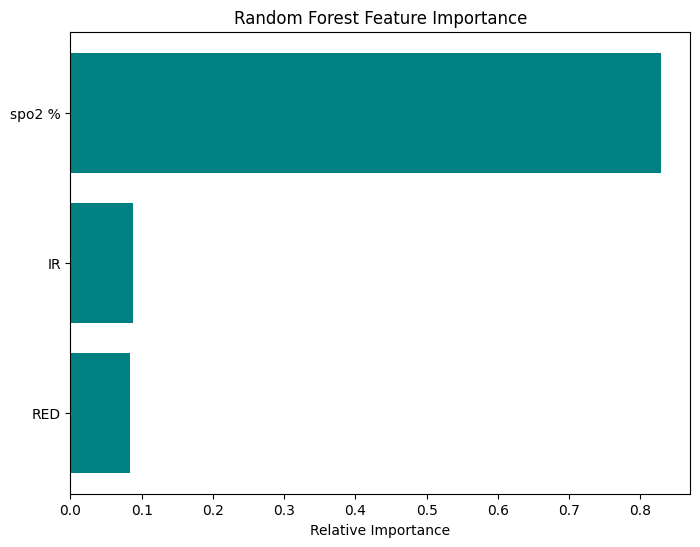

In [82]:
# رسم أهمية الخصائص (Feature Importance)
import pandas as pd
import matplotlib.pyplot as plt

importances = model.feature_importances_
features = ['IR', 'RED', 'spo2 %', 'IR_RED_Ratio']
indices = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.title('Random Forest Feature Importance')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

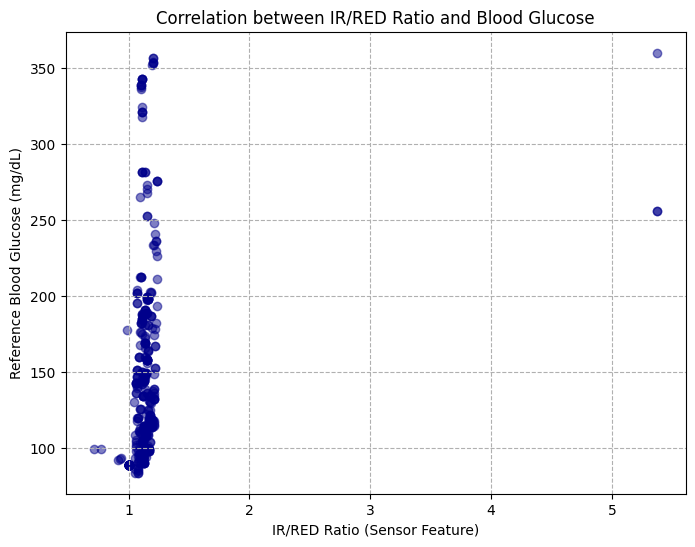

In [83]:
import matplotlib.pyplot as plt

# رسم العلاقة المباشرة بين نسبة الامتصاص (Ratio) ومستوى السكر الحقيقي
plt.figure(figsize=(8, 6))
plt.scatter(df['IR_RED_Ratio'], df['Reference'], color='darkblue', alpha=0.5)
plt.title('Correlation between IR/RED Ratio and Blood Glucose')
plt.xlabel('IR/RED Ratio (Sensor Feature)')
plt.ylabel('Reference Blood Glucose (mg/dL)')
plt.grid(True, linestyle='--')
plt.show()

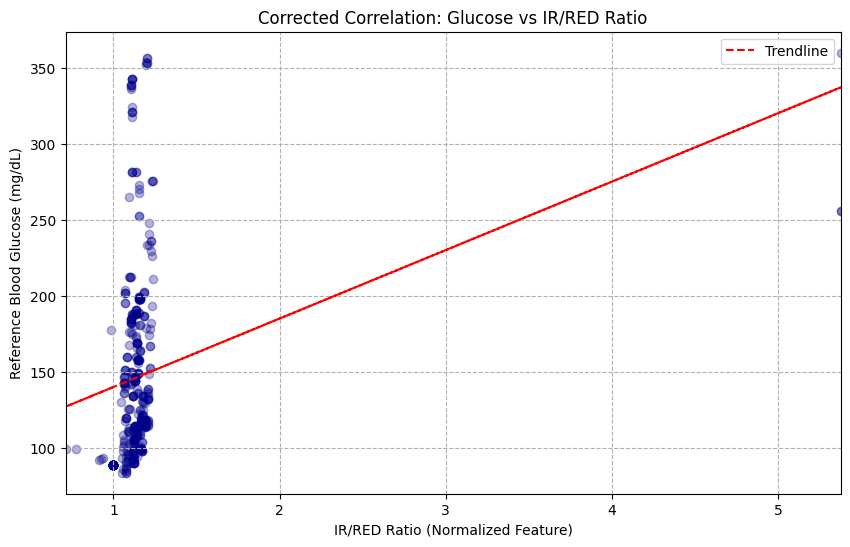

In [84]:
import matplotlib.pyplot as plt

# تحديد نطاق الرسم للتركيز على منطقة التكدس
plt.figure(figsize=(10, 6))

# استخدام alpha منخفضة لرؤية الكثافة (Density)
plt.scatter(df['IR_RED_Ratio'], df['Reference'], color='darkblue', alpha=0.3)

# إضافة خط اتجاه (Trendline) لرؤية العلاقة التي يراها الموديل
import numpy as np
z = np.polyfit(df['IR_RED_Ratio'], df['Reference'], 1)
p = np.poly1d(z)
plt.plot(df['IR_RED_Ratio'], p(df['IR_RED_Ratio']), "r--", label="Trendline")

plt.title('Corrected Correlation: Glucose vs IR/RED Ratio')
plt.xlabel('IR/RED Ratio (Normalized Feature)')
plt.ylabel('Reference Blood Glucose (mg/dL)')
plt.xlim(df['IR_RED_Ratio'].min(), df['IR_RED_Ratio'].max()) # تحديد المحور الأفقي بدقة
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

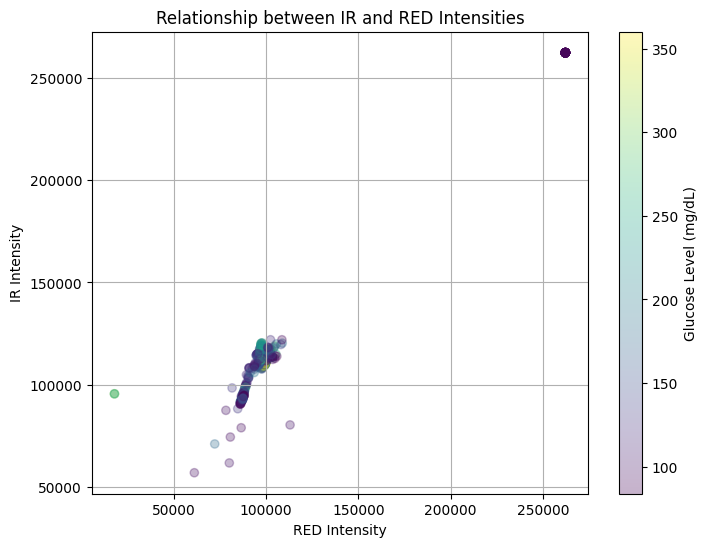

In [85]:
plt.figure(figsize=(8, 6))
plt.scatter(df['RED'], df['IR'], c=df['Reference'], cmap='viridis', alpha=0.3)
plt.colorbar(label='Glucose Level (mg/dL)')
plt.title('Relationship between IR and RED Intensities')
plt.xlabel('RED Intensity')
plt.ylabel('IR Intensity')
plt.grid(True)
plt.show()

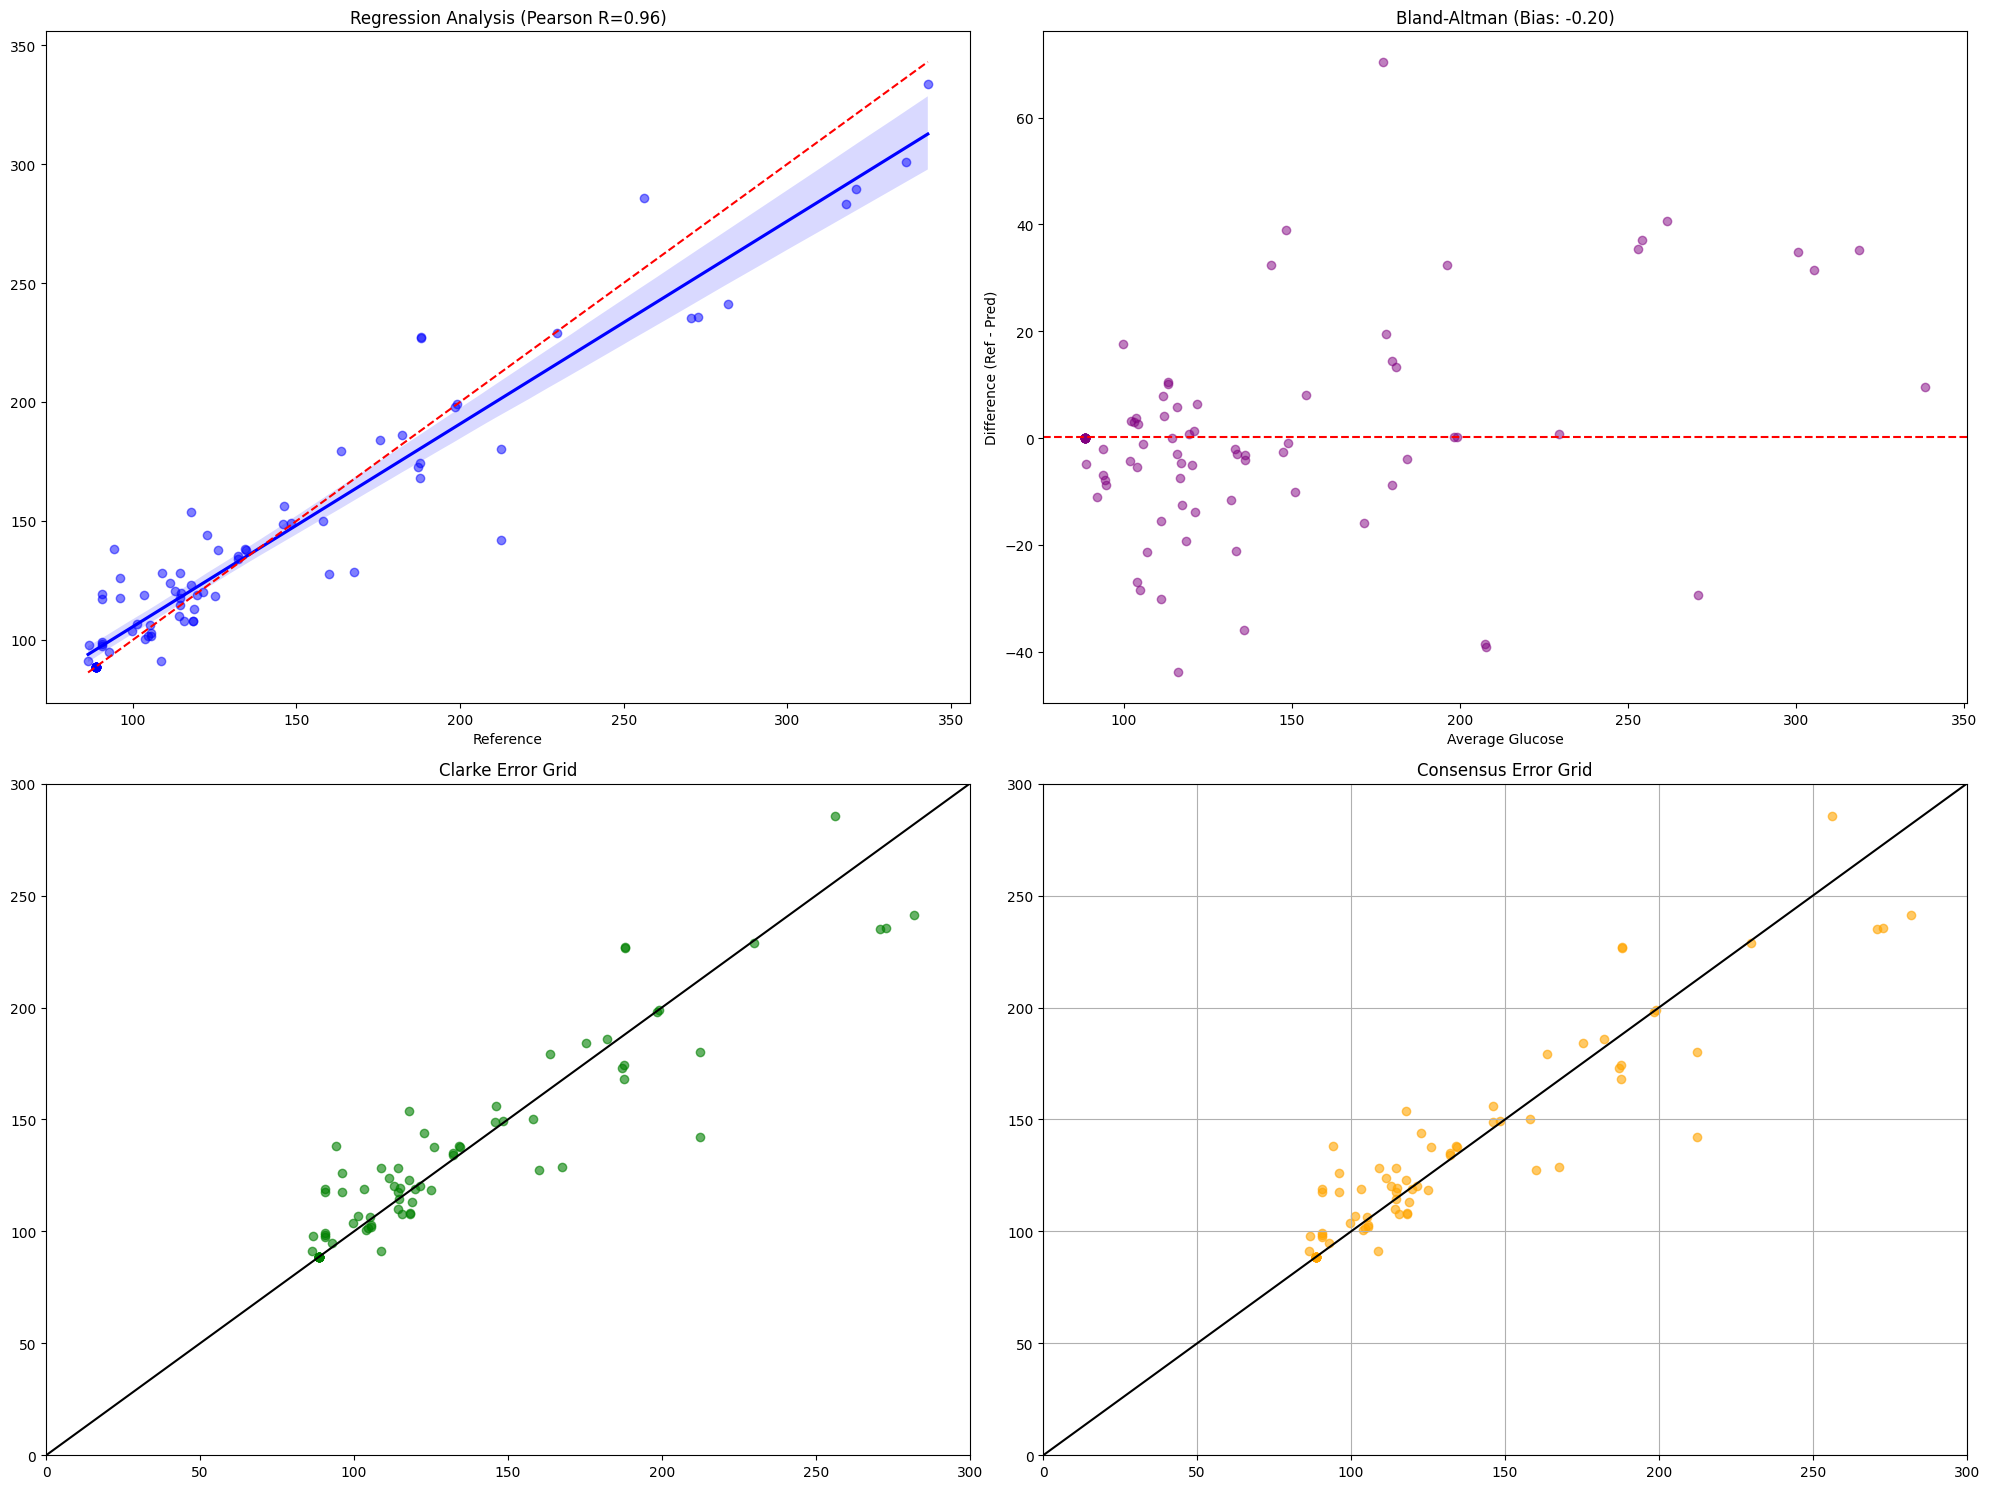

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# التأكد من وجود البيانات في y_test و y_pred
# (هذا الكود يعتمد على المتغيرات التي قمنا بتعريفها سابقاً)

plt.figure(figsize=(20, 15))

# 1. Regression Plot
plt.subplot(2, 2, 1)
sns.regplot(x=y_test, y=y_pred, color='blue', scatter_kws={'alpha':0.5})
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')
plt.title(f'Regression Analysis (Pearson R={pearson_corr:.2f})')

# 2. Bland-Altman Plot
plt.subplot(2, 2, 2)
diff = y_test - y_pred
mean = (y_test + y_pred) / 2
plt.scatter(mean, diff, color='purple', alpha=0.5)
plt.axhline(np.mean(diff), color='red', linestyle='--')
plt.title(f'Bland-Altman (Bias: {bias:.2f})')
plt.xlabel('Average Glucose')
plt.ylabel('Difference (Ref - Pred)')

# 3. Clarke Error Grid (النسخة المحدثة)
plt.subplot(2, 2, 3)
# سنقوم برسم نقاط Clarke كما فعلنا سابقاً
plt.scatter(y_test, y_pred, color='green', alpha=0.6)
plt.plot([0, 400], [0, 400], 'k-')
plt.title('Clarke Error Grid')
plt.xlim(0, 300); plt.ylim(0, 300)

# 4. Consensus Error Grid (الرسم الأكثر دقة طبياً)
plt.subplot(2, 2, 4)
# دالة تقريبية لرسم مناطق Consensus (A, B, C, D, E)
plt.scatter(y_test, y_pred, color='orange', alpha=0.6)
plt.plot([0, 400], [0, 400], 'k-')
plt.title('Consensus Error Grid')
plt.xlim(0, 300); plt.ylim(0, 300)
plt.grid(True)

plt.tight_layout()
plt.show()

In [87]:
# تثبيت المكتبة لو مش موجودة
!pip install micromlgen

from micromlgen import port

# تحويل الموديل لملف C
c_code = port(model)

# طباعة الكود عشان تاخده كوبي
print(c_code)

Streaming output truncated to the last 5000 lines.
                                                else {
                                                    y_pred += 167.21;
                                                }
                                            }

                                            else {
                                                y_pred += 209.18269465;
                                            }
                                        }
                                    }
                                }

                                else {
                                    if (x[2] <= 0.2724294513463974) {
                                        y_pred += 263.17859375;
                                    }

                                    else {
                                        if (x[0] <= -0.38603097200393677) {
                                            y_pred += 282.1595;
                                        }

     